## Stock Analysis of Germany's Automobile Industry

This project aims to provide insight into the current state of the German automobile market.
The analysis seeks to explore both the industry as a whole and the individual companies within it.

Ultimately, the goal is to answer - or at least gain well-founded insights into the following questions: 

    1) Which German automobile brand has had the most successful quarter?
    2) What political events took influence on the companys stock prices? 
    3) How do German car companies compare to international competitors and different German industries? 

The analysis focusses on the brands BMW, Mercedes, Porsche and VW:

In [1]:
ticker_symbols = ["BMW.DE", "MBG.DE", "P911.DE", "VOW3.DE"]

### Loading the Data 

In [2]:
# Importing Packages 
import yfinance as yf 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [15]:
# Importing Data

In [3]:
api_key = '...' # Feel free to enter your own api key 

In [16]:
import requests
import json 

def load_datasets_from_api(ticker_symbol, api_key): 
    url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={ticker_symbol}&apikey={api_key}'
    response = requests.get(url) 
    response_json = response.json()
    response_json_values = response_json['Time Series (Daily)']

    # Dissecting Values from JSON File 
    open = [float(response_json_values[x]['1. open']) for x in list(response_json_values.keys())]
    high = [float(response_json_values[x]['2. high']) for x in list(response_json_values.keys())]
    low = [float(response_json_values[x]['3. low']) for x in list(response_json_values.keys())]
    close = [float(response_json_values[x]['4. close']) for x in list(response_json_values.keys())]
    volume = [float(response_json_values[x]['5. volume']) for x in list(response_json_values.keys())]
    time = list(response_json_values.keys())

    # Creating Data Frame 
    dataframe = pd.DataFrame({"time": time, "open": open, "high": high, "low": low, "close": close, "volume": volume}, columns=["time","open","high","low","close","volume"])

    dataframe.to_csv(f'Datasets/{ticker_symbol}.csv')
    
    return dataframe 

In [17]:
# Creating Frames for all companys 
for ticker in ticker_symbols: 
    # load_datasets_from_api(ticker, api_key)
    pass

In [36]:
# In order to limit api usage and not reveal my api key I downloaded the data and will use the downloaded files from now on

In [18]:
bmw_df = pd.read_csv("Datasets/BMW.DE.csv")
mercedes_df = pd.read_csv("Datasets/MBG.DE.csv")
porsche_df = pd.read_csv("Datasets/P911.DE.csv")
vw_df = pd.read_csv("Datasets/VOW3.DE.csv")

### Cleaning the Data 

Before analyzing the data the dataframes should be checked for purity and general need for further preprocessing. 

To do so pandas provides some suitable functions: 

In [10]:
bmw_df.head()

,Unnamed: 0,time,open,high,low,close,volume
0,0,2025-04-11,66.14,66.54,64.58,66.36,1450181.0
1,1,2025-04-10,72.46,72.46,64.88,65.10,3049803.0
2,2,2025-04-09,63.28,66.30,62.96,63.52,2543401.0
3,3,2025-04-08,68.10,68.38,65.56,65.68,2500292.0
4,4,2025-04-07,64.80,71.06,63.86,67.08,4505056.0


Looking at the dataframe it gets clear that while importing an unnecessary column was added. 
On top of that as the data represents a time series there is no need for a separate index column, which should be replaced by the time.

In [11]:
bmw_df.describe()

,Unnamed: 0,open,high,low,close,volume
count,100.000000,100.0000,100.000000,100.000000,100.000000,1.000000e+02
mean,49.500000,77.2898,78.569200,76.248200,77.341000,1.460466e+06
std,29.011492,5.2497,5.304624,5.280657,5.379799,6.604563e+05
min,0.000000,63.2800,66.300000,62.960000,63.520000,4.561550e+05
25%,24.750000,75.3050,76.485000,74.315000,75.835000,1.018038e+06
50%,49.500000,77.8800,78.780000,76.910000,77.920000,1.320668e+06
75%,74.250000,80.2950,81.965000,79.295000,80.875000,1.806653e+06
max,99.000000,85.9800,88.260000,85.380000,86.980000,4.505056e+06


In [12]:
bmw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   time        100 non-null    object 
 2   open        100 non-null    float64
 3   high        100 non-null    float64
 4   low         100 non-null    float64
 5   close       100 non-null    float64
 6   volume      100 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 5.6+ KB


The info count seems promising - showing that there are no missing values. 
As this is crucial all dataframes should be checked:

In [19]:
def check_dfs_for_missing_values(df_list): 
    for index, df in enumerate(df_list): 
        print(f'Dataframe {index} has {str(df.isnull().sum().sum())} missing values.') 
check_dfs_for_missing_values([bmw_df, mercedes_df, porsche_df, vw_df])

Dataframe 0 has 0 missing values.
Dataframe 1 has 0 missing values.
Dataframe 2 has 0 missing values.
Dataframe 3 has 0 missing values.


Furthermore the info shows that the time column currently isn't storing the dates as a date but rather as a string, which might be laborious later on. 

There is thus mainly a need for changing the columns, which is done with the following function.

Note that there is no need for creating a new dataframe, however I do so to maintain the dataframes original form for the presentation above.

In [20]:
def preprocessing(dataframe): 
    # Deleting the unnecessary column 
    new_df = dataframe.drop(dataframe.columns[0], axis=1)

    # Changing datatype of the time column 
    new_df["time"] = pd.to_datetime(new_df["time"])
    
    # Replacing the index column with the time 
    new_df = new_df.set_index("time")
    
    return new_df 

In [21]:
processed_bmw_df = preprocessing(bmw_df)
processed_mercedes_df = preprocessing(mercedes_df) 
processed_porsche_df = preprocessing(porsche_df) 
processed_vw_df = preprocessing(vw_df) 

## Analysis 

#### Closing Prices

Now the data is prepared for some first visualization, starting with a comparison of the closing prices

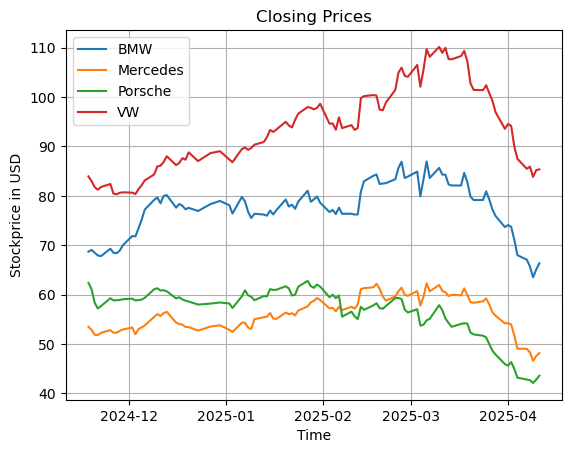

In [22]:
plt.title("Closing Prices") 
plt.plot(processed_bmw_df.index, processed_bmw_df['close'], label="BMW")
plt.plot(processed_bmw_df.index, processed_mercedes_df['close'], label="Mercedes")
plt.plot(processed_bmw_df.index, processed_porsche_df['close'], label="Porsche")
plt.plot(processed_bmw_df.index, processed_vw_df['close'], label="VW")
plt.xlabel("Time")
plt.ylabel("Stockprice in USD")
plt.grid(True)
plt.legend()
%matplotlib inline

All companies seem to have experienced a period of growth, that abruptly ended in march, when stock prices started to fall again -  a trend continuing in april. (1) 

An exception to this trend is Porsche, whose stock performed especially bad, with prices even falling behind its competitor Mercedes in february. (2) 

(1) 
The sudden drop in march can be traced back to the announcement of US tariffs, which led to fear in investors and generally raised a negative outlook on the stock market - especially in an affected industry like automobiles.

Source: 
https://www.handelsblatt.com/finanzen/maerkte/marktberichte/dax-aktuell-auto-aktien-rutschen-nach-zoll-ankuendigung-ab/100116842.html

(2)
Looking at reports confirms this supposition. Porsche is facing trouble with low demand in China, even leading CEO Oliver Blume to lower expexctations for midterm goals. 

Source: 
https://www.manager-magazin.de/unternehmen/porsche-gewinneinbruch-durch-china-flaute-und-hohe-kosten-a-563e5da5-aa4e-4fd3-8bb8-c7bba2756ad3

#### Weekly and Monthly Moving Averages 

To gain a clearer view of the performance, we'll smooth out some fluctuations by examining moving averages:

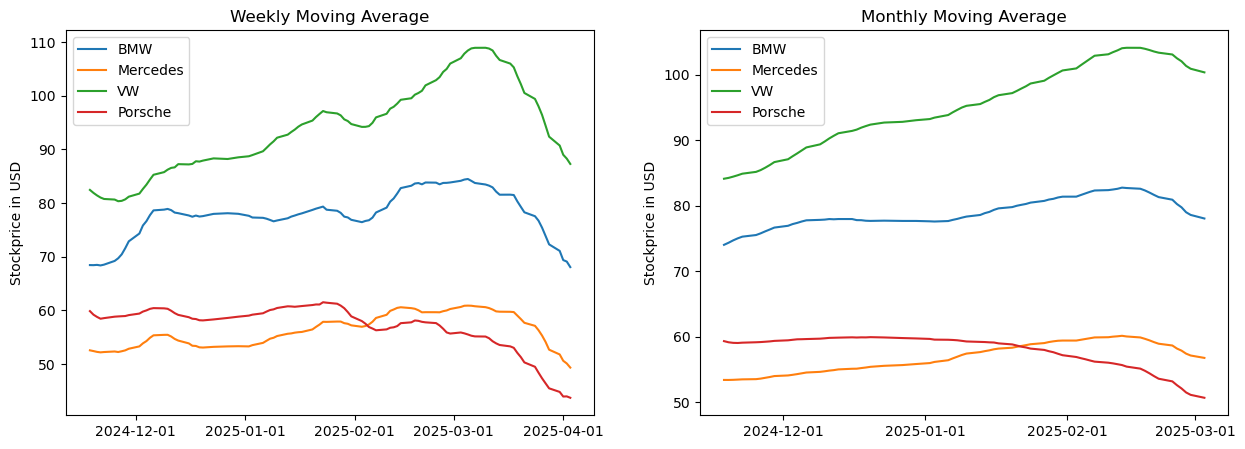

In [24]:
fig, axs = plt.subplots(1,2, figsize=(15,5))
axs[0].set_title("Weekly Moving Average")
axs[1].set_title("Monthly Moving Average") 

axs[0].set_ylabel("Stockprice in USD")
axs[1].set_ylabel("Stockprice in USD")

stocks = ["BMW", "Mercedes", "VW", "Porsche"]

time = processed_bmw_df.index
weekly_averages = [processed_bmw_df['open'].rolling(7).mean().dropna(), processed_mercedes_df['open'].rolling(7).mean().dropna(),
           processed_vw_df['open'].rolling(7).mean().dropna(), processed_porsche_df['open'].rolling(7).mean().dropna()]
monthly_averages = [processed_bmw_df['open'].rolling(30).mean().dropna(), processed_mercedes_df['open'].rolling(30).mean().dropna(),
           processed_vw_df['open'].rolling(30).mean().dropna(), processed_porsche_df['open'].rolling(30).mean().dropna()]

for i in range(4): 
    axs[0].plot(time[6:], weekly_averages[i], label=stocks[i])
    axs[1].plot(time[29:], monthly_averages[i], label=stocks[i])

axs[0].set_xticks(["2024-12", "2025-01", "2025-02", "2025-03", "2025-04" ])
axs[0].legend()
axs[1].legend()
axs[1].set_xticks(["2024-12", "2025-01", "2025-02", "2025-03"])
%matplotlib inline

The monthly moving average suggests that the stock movements of BMW, Mercedes, and VW are relatively similar, with VW showing a slight outperformance compared to its competitors. 

However, the impact of tariffs, while not immediately apparent in the monthly moving average, is clearly evident in the weekly moving average, highlighting its severity. 

Unlike the monthly view, the weekly moving average indicates that VW's stock appears to be more significantly affected by the tariffs than those of its competitors.

#### Volatility

Another metric to consider is the stocks' volatilty.

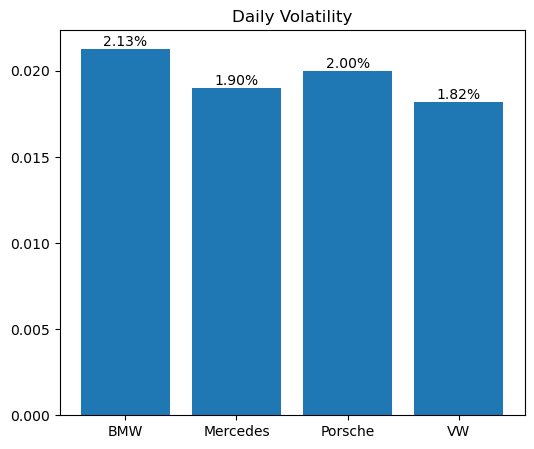

In [34]:
# Calculating Volatilit

def calculate_volatility(dataframe):
    return np.std(np.log((dataframe['close'].shift(1)/dataframe['close']).dropna()))

bmw_vl = calculate_volatility(processed_bmw_df)
mercedes_vl = calculate_volatility(processed_mercedes_df)
porsche_vl = calculate_volatility(processed_porsche_df)
vw_vl = calculate_volatility(processed_vw_df)

# Plotting
fig, axs = plt.subplots(1,1, figsize=(6,5))
axs.set_title("Daily Volatility")
axs.set_yticks(np.arange(0.00, 0.025, 0.005))

bar_container = axs.bar(["BMW", "Mercedes", "Porsche", "VW" ], [bmw_vl, mercedes_vl, porsche_vl, vw_vl])
axs.bar_label(bar_container, [f'{round(x*100, 2):.2f}%' for x in [bmw_vl, mercedes_vl, porsche_vl, vw_vl]])

%matplotlib inline

The stocks seem to have rather comparable volatility, with BMW and VW being the outliers.

This can be interpreted as VW having been the most stable in the last 100 days, while BMW was more affected by price changes.

In conclusion the data suggests that all four companies seem to have had a pretty rough quarter, especially affected by the US' tariff announcement. While the Porsche stock seems to have developed the worst, VW's data shows a potentially upcoming bad reaction to the announcement. 

## Comparison to the DAX

To answer the third question the stocks will now be compared to their index.

In [26]:
# Importing and cleaning with the functions from above
#dax_df = load_datasets_from_api("DAX", api_key)
dax_df = pd.read_csv("Datasets/DAX.csv")
processed_dax_df = preprocessing(dax_df)
check_dfs_for_missing_values([processed_dax_df])

Dataframe 0 has 0 missing values.


#### Alpha and Beta Values 

In [27]:
def calculate_beta_value(df_index, df_company):
    # Calculate daily log returns
    returns_index = np.log(df_index['close'].shift(1) / df_index['close']).dropna()
    returns_company = np.log(df_company['close'].shift(1) / df_company['close']).dropna()
    returns_index, returns_company = returns_index.align(returns_company, join='inner')

    covariance = np.cov(returns_index, returns_company)[0, 1]
    variance_market = np.var(returns_index)

    return covariance / variance_market

def calculate_alpha_value(df_index, df_company, rfr=0.03):
    # Calculate total return for the index and company
    returns_index = np.log(df_index['close'].iloc[0] / df_index['close'].iloc[-1])
    returns_company = np.log(df_company['close'].iloc[0] / df_company['close'].iloc[-1])

    # Beta value
    beta = calculate_beta_value(df_index, df_company)

    # Alpha calculation
    return returns_company - (rfr + beta * (returns_index - rfr))


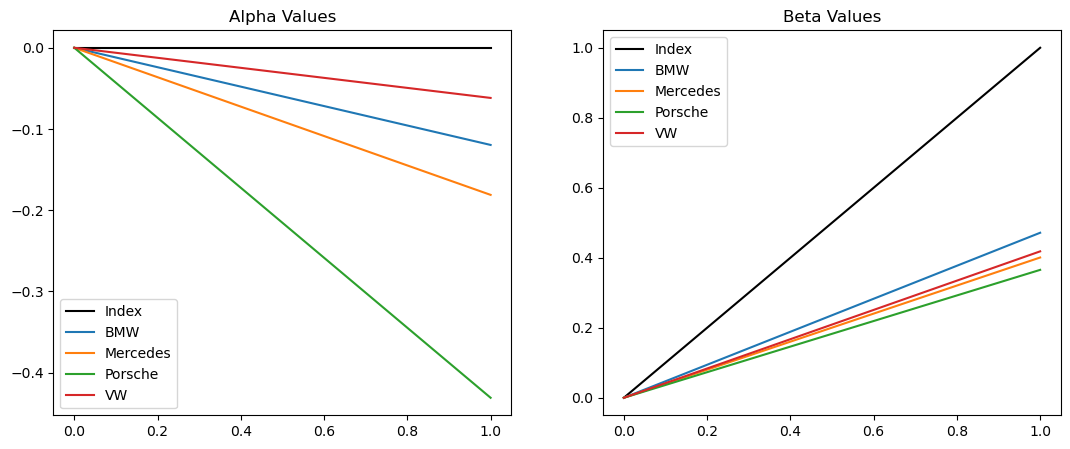

In [28]:
# Visualization 
fig, axs = plt.subplots(1,2,figsize=(13,5))

stocks = {"BMW": processed_bmw_df, "Mercedes": processed_mercedes_df, "Porsche": processed_porsche_df, "VW": processed_vw_df}
betavalues = {key:calculate_beta_value(processed_dax_df, stocks[key]) for key in list(stocks.keys())}
alphavalues = {key:calculate_alpha_value(processed_dax_df, stocks[key]) for key in stocks.keys()}

# Visualization - Alpha
axs[0].set_title("Alpha Values")
axs[0].plot([0,0], label="Index", color="0")
for stock in alphavalues.keys(): 
    axs[0].plot([0,alphavalues[stock]], label=stock)
axs[0].legend()

# Visualization - Beta
axs[1].set_title("Beta Values")
axs[1].plot([0,1], label="Index", color="0")
for stock in alphavalues.keys(): 
    axs[1].plot([0,betavalues[stock]], label=stock)
axs[1].legend()

%matplotlib inline

Calculating the beta value produces a counterintuitive result, indicating that the industry exhibits unusually low volatility relative to the market. This observation is surprising, as the automobile industry is typically not associated with such low volatility. While this anomaly might be attributed to current market dynamics, it could also stem from an insufficiently long observation period, which should be considered when interpreting the results.

On the other hand, the alpha values —though inherently linked to the beta values— align with expectations. They reveal that the automobile industry is underperforming relative to the market index, which is consistent with broader industry trends.

Source supporting this observation:
https://www.tagesschau.de/wirtschaft/unternehmen/deutsche-autobauer-krise-100.html

## Comparison to international competitors - Tesla and Toyota

In [30]:
# Importing and cleaning with the functions from above
#toyota_df = load_datasets_from_api("TM", "...")
#tesla_df = load_datasets_from_api("TSLA", "...")

toyota_df = pd.read_csv("Datasets/DAX.csv")
tesla_df = pd.read_csv("Datasets/TSLA.csv")

processed_toyota_df = preprocessing(toyota_df)
processed_tesla_df = preprocessing(tesla_df)

#### Closing Prices and Volatility

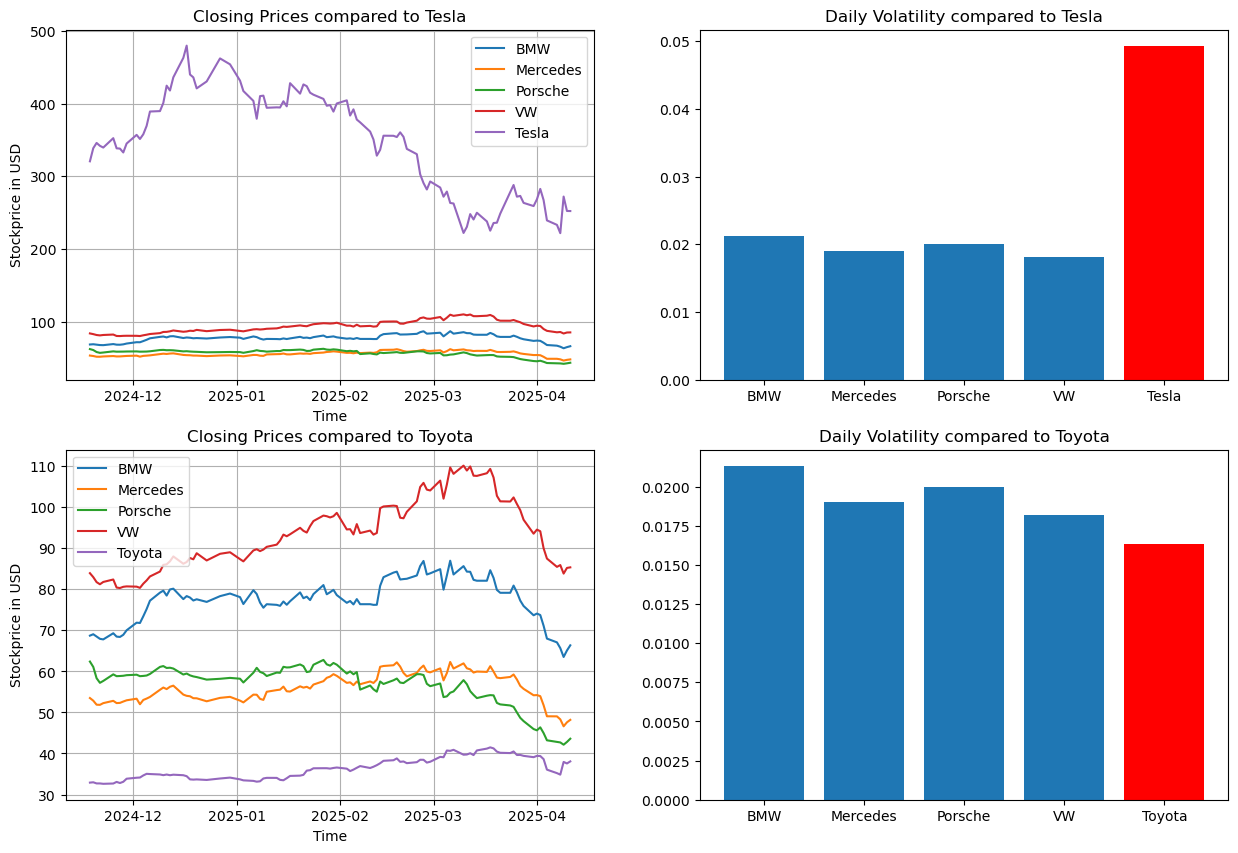

In [31]:
fig, axs = plt.subplots(2,2,figsize=(15,10))

# Closing Prices compared to Tesla
dict = {"Tesla": processed_tesla_df, "Toyota": processed_toyota_df}

for index, stock in enumerate(list(dict.keys())): 

    # Closing Prices
    axs[index][0].set_title(f"Closing Prices compared to {stock}") 
    axs[index][0].plot(processed_bmw_df.index, processed_bmw_df['close'], label="BMW")
    axs[index][0].plot(processed_bmw_df.index, processed_mercedes_df['close'], label="Mercedes")
    axs[index][0].plot(processed_bmw_df.index, processed_porsche_df['close'], label="Porsche")
    axs[index][0].plot(processed_bmw_df.index, processed_vw_df['close'], label="VW")
    axs[index][0].plot(processed_bmw_df.index, dict[stock]['close'], label=stock)
    axs[index][0].set_xlabel("Time")
    axs[index][0].set_ylabel("Stockprice in USD")
    axs[index][0].grid(True)
    axs[index][0].legend()


    # Volatility 
    axs[index][1].set_title(f"Daily Volatility compared to {stock}")
    axs[index][1].bar(["BMW", "Mercedes", "Porsche", "VW", stock], 
           [np.std(np.log((processed_bmw_df['close']/processed_bmw_df['close'].shift(1)).dropna())),
            np.std(np.log((processed_mercedes_df['close']/processed_mercedes_df['close'].shift(1)).dropna())),
            np.std(np.log((processed_porsche_df['close']/processed_porsche_df['close'].shift(1)).dropna())),
            np.std(np.log((processed_vw_df['close']/processed_vw_df['close'].shift(1)).dropna())),
            np.std(np.log((dict[stock]['close']/dict[stock]['close'].shift(1)).dropna()))],
          color=["C0","C0","C0","C0","r"])




Compared to German automobile companies, Tesla appears to have underperformed significantly in the last quarter. This underperformance may not be entirely attributable to factors related to the automobile industry, but also to its CEO Elon Musk's political involvement. Notably, Tesla's stock exhibits exceptionally high volatility, nearly 5%, which might be driven by its immense popularity among investors.

Source: https://www.deraktionaer.de/artikel/mobilitaet-oel-energie/tesla-erneut-unter-druck-reihenweise-purzeln-die-kursziele-jetzt-verkaufen-20378338.html


In contrast, the Japanese competitor's stock has demonstrated greater stability compared to its German counterparts. While its growth appears more modest, this is balanced by substantially lower volatility, reflecting a steadier performance overall.

#### Return per Share

To conclude we should also look at a rather easy metric - the return per share:

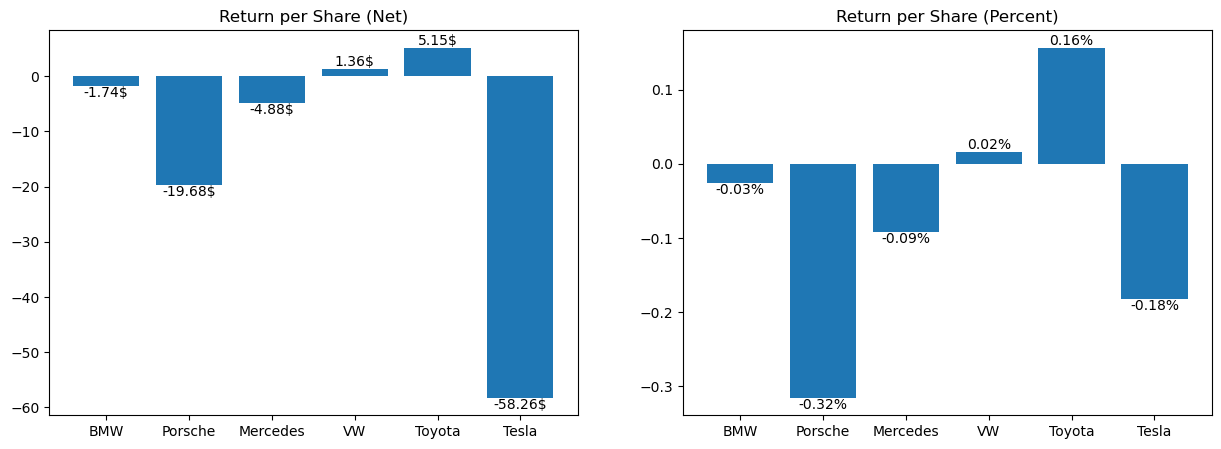

In [221]:
fig, axs = plt.subplots(1,2, figsize=(15,5))

profit = [processed_bmw_df['close'].iloc[0]-processed_bmw_df['open'].iloc[-1],
                 processed_porsche_df['close'].iloc[0]-processed_porsche_df['open'].iloc[-1],
                 processed_mercedes_df['close'].iloc[0]-processed_mercedes_df['open'].iloc[-1],
                 processed_vw_df['close'].iloc[0]-processed_vw_df['open'].iloc[-1],
                 processed_toyota_df['close'].iloc[0]-processed_toyota_df['open'].iloc[-1],
                 processed_tesla_df['close'].iloc[0]-processed_tesla_df['open'].iloc[-1],
                 ]
profit_prct = [profit[0] / processed_bmw_df['close'].iloc[-1],
               profit[1] / processed_porsche_df['close'].iloc[-1],
               profit[2] / processed_mercedes_df['close'].iloc[-1],
               profit[3] / processed_vw_df['close'].iloc[-1],
               profit[4] / processed_toyota_df['close'].iloc[-1],
               profit[5] / processed_tesla_df['close'].iloc[-1],
              ]


axs[0].set_title("Return per Share (Net)")
axs[1].set_title("Return per Share (Percent)")
container = axs[0].bar(["BMW", "Porsche", "Mercedes","VW", "Toyota", "Tesla"], profit)
container_prct = axs[1].bar(["BMW", "Porsche", "Mercedes","VW", "Toyota", "Tesla"], profit_prct)
axs[0].bar_label(container, [f'{x:.2f}$' for x in profit])
axs[1].bar_label(container_prct, [f'{x:.2f}%' for x in profit_prct])
%matplotlib inline


This plot supports the previous analysis. While all German automobile companys seem to have had a challenging quarter, Porsche's performance stands out as particularly poor.

Mercedes, BMW and Volkswagen have shown relatively similar trends, although Volkswagen's stock appears slightly more stable compared to the other two.

On the international front, the US competitor Tesla seems to amplify market movement a lot more, leading to it mostly underperforming German companys. In contrast, the Japanese competitor Toyota demonstrated notable stability, outperforming its peers in the last quarter by showing greater resilience to the current crisis.